# EDA 
(Exploratory Data Analysis)

es el proceso de explorar y entender un dataset antes de hacer conclusiones o modelos. El objetivo es detectar patrones, problemas en los datos y posibles insights de negocio.
Respondiendo a prenguntas como:
- ¿Cuantas ventas mensuales tenemos?
- ¿Cuanto es el porcentaje de devoluciones totales?
- ¿Que productos son los mas vendidos?
- ¿Que productos estan de moda?
- ¿En que pais se consumen?

Cargar datos

In [30]:
import pandas as pd
import numpy as np  
df_sales = pd.read_csv(r"C:\Users\ferra\OneDrive\Documentos\Data Projects\ecommerce-sales-analysis\data\proccesed\df_sales.csv")
df_returns = pd.read_csv(r"C:\Users\ferra\OneDrive\Documentos\Data Projects\ecommerce-sales-analysis\data\proccesed\df_return.csv")

print("Ventas")
#print(df_sales.info)
print("Devoluciones")
print(df_returns)

Ventas
Devoluciones
       Invoice StockCode                       Description  Quantity  \
0      C489449     22087          PAPER BUNTING WHITE LACE       -12   
1      C489449    85206A      CREAM FELT EASTER EGG BASKET        -6   
2      C489449     21895     POTTING SHED SOW 'N' GROW SET        -4   
3      C489449     21896                POTTING SHED TWINE        -6   
4      C489449     22083        PAPER CHAIN KIT RETRO SPOT       -12   
...        ...       ...                               ...       ...   
10200  C538123     22956          36 FOIL HEART CAKE CASES        -2   
10201  C538124         M                            Manual        -4   
10202  C538124     22699  ROSES REGENCY TEACUP AND SAUCER         -1   
10203  C538124     22423          REGENCY CAKESTAND 3 TIER        -1   
10204  C538164    35004B       SET OF 3 BLACK FLYING DUCKS        -1   

               InvoiceDate  Price  Customer ID         Country  
0      2009-12-01 10:33:00   2.95      16321.0    

C:\Users\ferra\AppData\Local\Temp\ipykernel_12556\2411495163.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sales = pd.read_csv(r"C:\Users\ferra\OneDrive\Documentos\Data Projects\ecommerce-sales-analysis\data\proccesed\df_sales.csv")


Garantizar que los tipos de datos se mantengan (Pandas no garantiza que los d.types se mantengan en la memoria)

In [31]:
for d in [df_sales, df_returns]:
    d['InvoiceDate'] = pd.to_datetime(d['InvoiceDate'], errors='coerce')
    d['Quantity'] = pd.to_numeric(d['Quantity'], errors='coerce')
    d['Price'] = pd.to_numeric(d['Price'], errors='coerce')
    d['Revenue'] = d['Quantity'] * d['Price']
    d['YearMonth'] = d['InvoiceDate'].dt.to_period('M').astype(str)


# Calcular ventas

In [32]:
sales_monthly = (
    df_sales.groupby('YearMonth', as_index=False)['Revenue']
    .sum()
    .sort_values('YearMonth')
)
sales_monthly['Revenue'] = sales_monthly['Revenue'].round(2)

print("=== Ventas mensuales ===")
print(sales_monthly.to_string(index=False))

=== Ventas mensuales ===
YearMonth    Revenue
  2009-12  825685.76
  2010-01  652708.50
  2010-02  553713.31
  2010-03  833570.13
  2010-04  681528.99
  2010-05  659858.86
  2010-06  752270.14
  2010-07  650712.94
  2010-08  697274.91
  2010-09  924333.01
  2010-10 1165483.91
  2010-11 1470272.48
  2010-12  438852.65


# Devoluciones mensuales

In [33]:
returns_monthly = (
    df_returns.groupby('YearMonth', as_index=False)['Revenue']
    .sum()
    .sort_values('YearMonth')
    )
returns_monthly['Revenue'] = -returns_monthly['Revenue']

print("\n=== Devoluciones mensuales ===")
print(returns_monthly.to_string(index=False))


=== Devoluciones mensuales ===
YearMonth  Revenue
  2009-12 25838.65
  2010-01 28675.61
  2010-02 20621.88
  2010-03 67721.37
  2010-04 37354.20
  2010-05 44536.03
  2010-06 72483.53
  2010-07 31444.79
  2010-08 40498.57
  2010-09 70682.58
  2010-10 81389.69
  2010-11 47617.84
  2010-12 61364.20


# Top 10 productos mas vendidos


=== Top 10 productos por ventas ===
StockCode                         Description   Revenue
        M                              Manual 262979.58
    22423            REGENCY CAKESTAND 3 TIER 170078.51
   85123A  WHITE HANGING HEART T-LIGHT HOLDER 158590.87
      DOT                      DOTCOM POSTAGE 116408.71
    84879       ASSORTED COLOUR BIRD ORNAMENT  73092.99
    22086     PAPER CHAIN KIT 50'S CHRISTMAS   58189.25
   85099B             JUMBO BAG RED RETROSPOT  54483.87
    47566                       PARTY BUNTING  49682.72
     POST                             POSTAGE  49477.54
    84347 ROTATING SILVER ANGELS T-LIGHT HLDR  47985.09


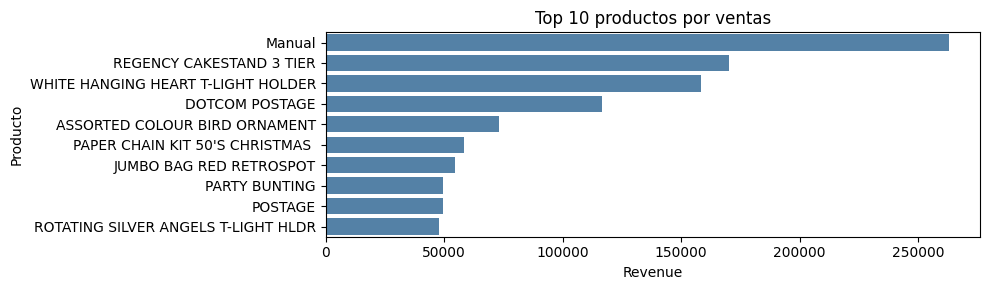

In [34]:
top_products = (
    df_sales.groupby(['StockCode','Description'], as_index=False)['Revenue']
    .sum()
    .sort_values('Revenue', ascending=False)
    .head(10)
)
print("\n=== Top 10 productos por ventas ===")
print(top_products.to_string(index=False))

import seaborn as sns
import matplotlib.pyplot as plt
top10 = top_products.head(10)

plt.figure(figsize=(10,3))
sns.barplot(data=top10, x='Revenue', y='Description', color='steelblue')
plt.title('Top 10 productos por ventas')
plt.xlabel('Revenue')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

# Tasa de devolución

In [35]:
gross_sales = df_sales['Revenue'].sum()
returns_amount = -df_returns['Revenue'].sum()
return_rate_amount = (returns_amount / gross_sales) * 100 if gross_sales else 0

print("\n=== Devoluciones ===")
print(f"Monto devuelto: {returns_amount:.2f}")
print(f"Tasa de devolución (monto): {return_rate_amount:.2f}%")


=== Devoluciones ===
Monto devuelto: 630228.94
Tasa de devolución (monto): 6.12%


Meses con mayor tasa de devoluciones por monto

In [36]:
# --- TASA POR MONTO (ventas vs devoluciones) ---
sales_m = df_sales.groupby('YearMonth', as_index=False)['Revenue'].sum()
returns_m = df_returns.groupby('YearMonth', as_index=False)['Revenue'].sum()
returns_m['Revenue'] = -returns_m['Revenue']  # pasar a positivo

month_rate = sales_m.merge(returns_m, on='YearMonth', how='left', suffixes=('_sales','_returns'))
month_rate['Revenue_returns'] = month_rate['Revenue_returns'].fillna(0)
month_rate['ReturnRateAmount'] = (month_rate['Revenue_returns'] / month_rate['Revenue_sales']) * 100

print(month_rate.sort_values('ReturnRateAmount', ascending=False).to_string(index=False))

YearMonth  Revenue_sales  Revenue_returns  ReturnRateAmount
  2010-12     438852.650         61364.20         13.982871
  2010-06     752270.140         72483.53          9.635306
  2010-03     833570.131         67721.37          8.124256
  2010-09     924333.011         70682.58          7.646874
  2010-10    1165483.910         81389.69          6.983339
  2010-05     659858.860         44536.03          6.749327
  2010-08     697274.910         40498.57          5.808121
  2010-04     681528.992         37354.20          5.480941
  2010-07     650712.940         31444.79          4.832360
  2010-01     652708.502         28675.61          4.393326
  2010-02     553713.306         20621.88          3.724288
  2010-11    1470272.482         47617.84          3.238709
  2009-12     825685.760         25838.65          3.129356


Paises con mayor tasa de devoluciones

In [37]:
sales_cty = df_sales.groupby('Country', as_index=False)['Revenue'].sum()
returns_cty = df_returns.groupby('Country', as_index=False)['Revenue'].sum()
returns_cty['Revenue'] = -returns_cty['Revenue']

country_rate = sales_cty.merge(returns_cty, on='Country', how='left', suffixes=('_sales','_returns'))
country_rate['Revenue_returns'] = country_rate['Revenue_returns'].fillna(0)
country_rate['ReturnRateAmount'] = (country_rate['Revenue_returns'] / country_rate['Revenue_sales']) * 100

print(country_rate.sort_values('ReturnRateAmount', ascending=False).to_string(index=False))

             Country  Revenue_sales  Revenue_returns  ReturnRateAmount
             Nigeria        140.390           147.05        104.743928
              Norway      23944.180         19864.61         82.962165
           Hong Kong       8202.520          4280.26         52.182256
               Malta       5373.500          2686.75         50.000000
                 RSA       3802.010          1435.29         37.750821
               Spain      47601.420         10516.52         22.092870
         Unspecified       6186.220          1248.69         20.185024
             Lebanon        211.700            39.67         18.738781
               Korea       1118.510           168.69         15.081671
               Japan       9722.020          1286.06         13.228321
     Channel Islands      24546.320          3179.00         12.951025
United Arab Emirates       9195.350          1148.98         12.495229
              France     147211.490         16441.59         11.168687
      

In [38]:
# Asegurar revenue
for d in [df_sales, df_returns]:
    d['Revenue'] = pd.to_numeric(d['Quantity'], errors='coerce') * pd.to_numeric(d['Price'], errors='coerce')


Top paises con mas ventas

In [39]:
# Totales por país
sales_cty = df_sales.groupby('Country', as_index=False)['Revenue'].sum()
returns_cty = df_returns.groupby('Country', as_index=False)['Revenue'].sum()
returns_cty['Revenue'] = -returns_cty['Revenue']

country = sales_cty.merge(returns_cty, on='Country', how='left', suffixes=('_sales','_returns'))
country['Revenue_returns'] = country['Revenue_returns'].fillna(0)
country['Revenue_net'] = country['Revenue_sales'] - country['Revenue_returns']
country['ReturnRateAmount'] = (country['Revenue_returns'] / country['Revenue_sales']) * 100


# Participación en ventas
total_sales = country['Revenue_sales'].sum()
country['ShareOfSales'] = (country['Revenue_sales'] / total_sales) * 100

print(country.sort_values('Revenue_sales', ascending=False).head(10).to_string(index=False))

       Country  Revenue_sales  Revenue_returns  Revenue_net  ReturnRateAmount  ShareOfSales
United Kingdom    8846129.263        514799.71  8331329.553          5.819491     85.832537
          EIRE     380977.820         28735.09   352242.730          7.542457      3.696565
   Netherlands     268786.000          4922.59   263863.410          1.831416      2.607986
       Germany     202395.321          6104.97   196290.351          3.016359      1.963809
        France     147211.490         16441.59   130769.900         11.168687      1.428369
        Sweden      53525.390          2311.88    51213.510          4.319221      0.519348
       Denmark      50906.850          3933.90    46972.950          7.727644      0.493941
         Spain      47601.420         10516.52    37084.900         22.092870      0.461869
   Switzerland      43921.390           577.98    43343.410          1.315942      0.426162
     Australia      31446.800          1395.00    30051.800          4.436063   

# Tikets y canastas

In [40]:
# Ticket por factura (AOV)
ticket = (
    df_sales.groupby('Invoice', as_index=False)['Revenue']
    .sum()
    .rename(columns={'Revenue':'Ticket'})
)

# Canasta: cantidad de items por factura
basket_qty = (
    df_sales.groupby('Invoice', as_index=False)['Quantity']
    .sum()
    .rename(columns={'Quantity':'Items'})
)

# Cantidad de productos distintos por factura
basket_unique = (
    df_sales.groupby('Invoice', as_index=False)['StockCode']
    .nunique()
    .rename(columns={'StockCode':'UniqueProducts'})
)

# Unir todo
basket = ticket.merge(basket_qty, on='Invoice').merge(basket_unique, on='Invoice')

print("=== Resumen tickets y canastas ===")
print(basket[['Ticket','Items','UniqueProducts']].describe().round(2))

# Si querés ver percentiles específicos:
print("\nPercentiles Ticket:")
print(basket['Ticket'].quantile([0.25,0.5,0.75,0.9,0.95]).round(2))

=== Resumen tickets y canastas ===
         Ticket     Items  UniqueProducts
count  20954.00  20954.00        20954.00
mean     491.85    278.32           23.78
std     1116.08   1368.94           38.35
min        0.19      1.00            1.00
25%      147.92     60.00            6.00
50%      300.79    141.00           15.00
75%      491.62    278.00           28.00
max    49844.99  87167.00          674.00

Percentiles Ticket:
0.25     147.92
0.50     300.79
0.75     491.62
0.90     920.58
0.95    1445.68
Name: Ticket, dtype: float64


Grafico Scatterplot para revelar patrones de compras:

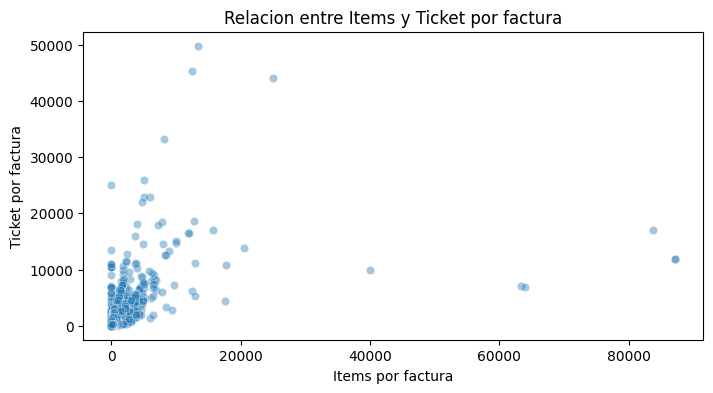

In [41]:

plt.figure(figsize=(8,4))
sns.scatterplot(data=basket, x='Items', y='Ticket', alpha=0.4)
plt.title('Relacion entre Items y Ticket por factura')
plt.xlabel('Items por factura')
plt.ylabel('Ticket por factura')
plt.show()


Tendencia de compra

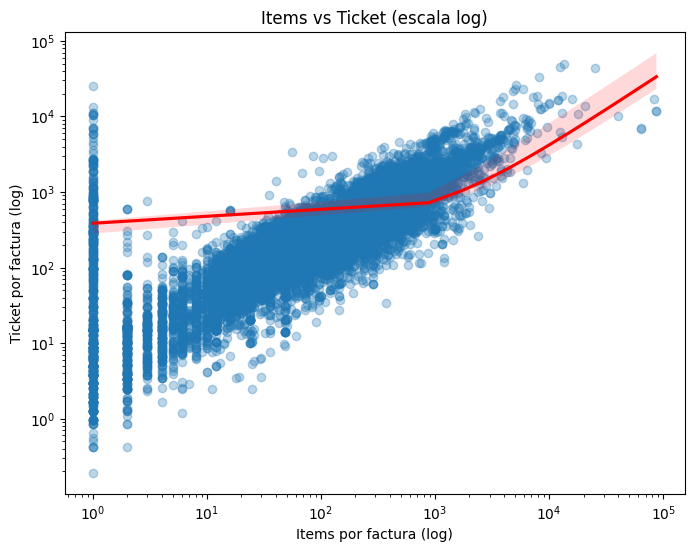

In [42]:
plt.figure(figsize=(8,6))
sns.regplot(
    data=basket, x='Items', y='Ticket',
    scatter_kws={'alpha':0.3}, line_kws={'color':'red'}
)
plt.xscale('log')
plt.yscale('log')
plt.title('Items vs Ticket (escala log)')
plt.xlabel('Items por factura (log)')
plt.ylabel('Ticket por factura (log)')
plt.show()

# Productos mas vendidos por mes

In [43]:
top_per_month = (
    df_sales.groupby(['YearMonth','StockCode','Description'], as_index=False)['Revenue']
    .sum()
    .sort_values(['YearMonth','Revenue'], ascending=[True, False])
    .groupby('YearMonth')
    .head(1)   # top 1 por mes
)

print(top_per_month.to_string(index=False))

YearMonth StockCode                        Description  Revenue
  2009-12       DOT                     DOTCOM POSTAGE 18574.58
  2010-01         M                             Manual 15621.17
  2010-02    85123A WHITE HANGING HEART T-LIGHT HOLDER  8030.57
  2010-03         M                             Manual 54911.62
  2010-04         M                             Manual 23367.46
  2010-05    85123A WHITE HANGING HEART T-LIGHT HOLDER 11967.49
  2010-06         M                             Manual 43177.02
  2010-07     22423           REGENCY CAKESTAND 3 TIER 18865.88
  2010-08     22423           REGENCY CAKESTAND 3 TIER 13271.28
  2010-09         M                             Manual 41085.05
  2010-10         M                             Manual 52738.38
  2010-11     22086    PAPER CHAIN KIT 50'S CHRISTMAS  28341.81
  2010-12 AMAZONFEE                         AMAZON FEE 13541.33


# Moda por crecimiento de producto

In [44]:
monthly_prod = (
    df_sales.groupby(['YearMonth','StockCode','Description'], as_index=False)['Revenue']
    .sum()
)

monthly_prod['Revenue_prev'] = (
    monthly_prod.sort_values('YearMonth')
    .groupby(['StockCode','Description'])['Revenue']
    .shift(1)
)

monthly_prod['GrowthPct'] = ((monthly_prod['Revenue'] - monthly_prod['Revenue_prev']) / monthly_prod['Revenue_prev']) * 100

# Top crecimientos por mes (evita divisiones raras)
growth_top = (
    monthly_prod[monthly_prod['Revenue_prev'] > 0]
    .sort_values(['YearMonth','GrowthPct'], ascending=[True, False])
    .groupby('YearMonth')
    .head(3)
)

print(growth_top.to_string(index=False))

YearMonth StockCode                         Description  Revenue  Revenue_prev    GrowthPct
  2010-01     20759          CHRYSANTHEMUM POCKET BOOK    565.83          2.55 22089.411765
  2010-01    47590B         PINK HAPPY BIRTHDAY BUNTING  1104.74          5.45 20170.458716
  2010-01    84925D        LA PALMIERA WALL THERMOMETER   460.70          2.55 17966.666667
  2010-02     22417      PACK OF 60 SPACEBOY CAKE CASES  1180.77          2.20 53571.363636
  2010-02     85220     SMALL FAIRY CAKE FRIDGE MAGNETS  6467.60         39.60 16232.323232
  2010-02     21313         GLASS HEART T-LIGHT HOLDER    271.65          1.70 15879.411765
  2010-03     21915              RED  HARMONICA IN BOX   1237.32          1.25 98885.600000
  2010-03     21967            PACK OF 12 SKULL TISSUES   247.08          0.29 85100.000000
  2010-03     22150            3 STRIPEY MICE FELTCRAFT  1046.28          1.95 53555.384615
  2010-04     84526              GIANT BLACK SUNGLASSES  1349.28          1.95 6

Top N productos por ingresos totales

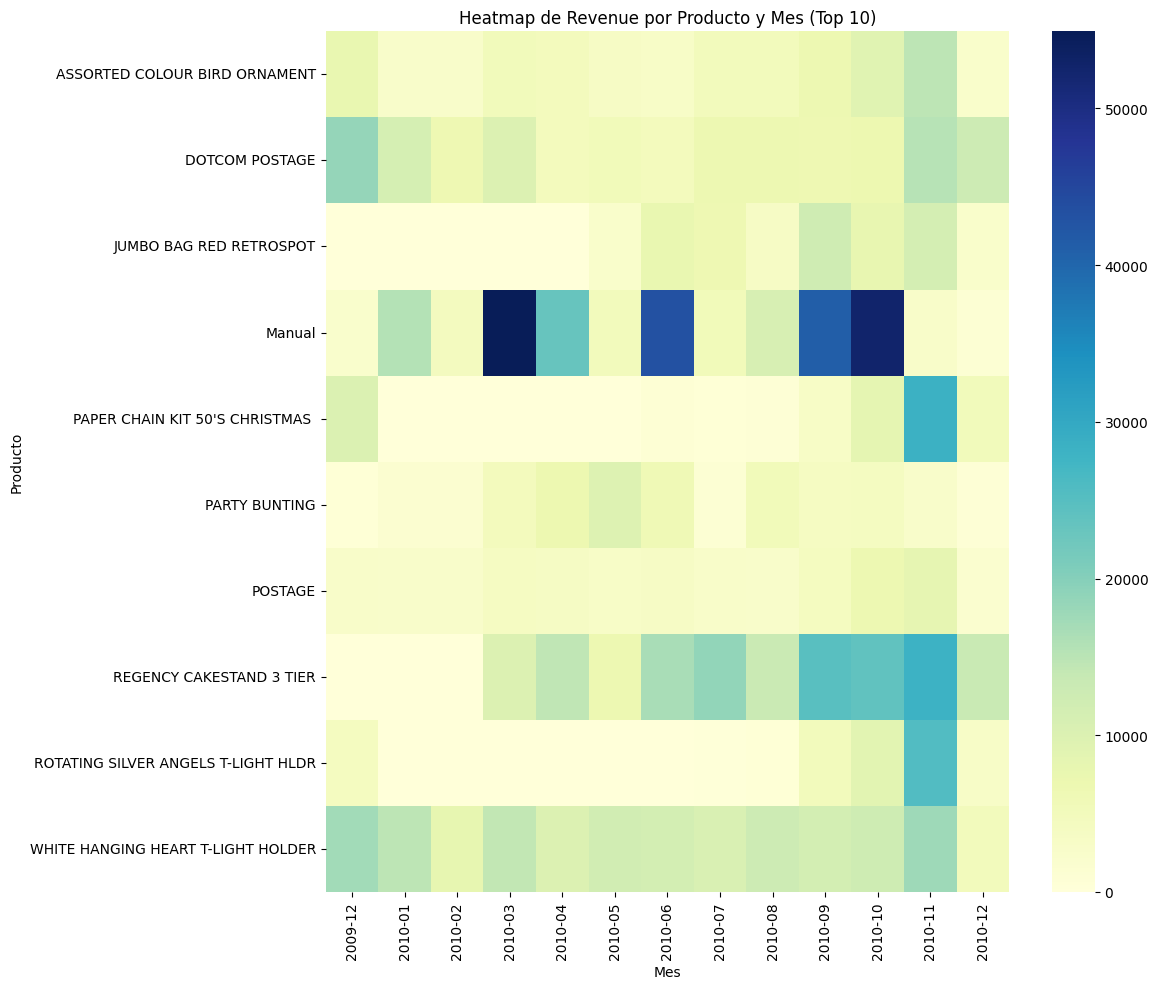

In [45]:
top_n = 10
top_products = (
    df_sales.groupby(['StockCode','Description'], as_index=False)['Revenue']
    .sum()
    .sort_values('Revenue', ascending=False)
    .head(top_n)
)

# Filtrar solo esos productos
df_top = df_sales.merge(top_products[['StockCode','Description']], on=['StockCode','Description'], how='inner')

# Pivot para heatmap
heat = (
    df_top.groupby(['Description','YearMonth'], as_index=False)['Revenue']
    .sum()
    .pivot(index='Description', columns='YearMonth', values='Revenue')
    .fillna(0)
)

# Ordenar columnas (YearMonth) cronológicamente
heat.columns = pd.PeriodIndex(heat.columns, freq='M').sort_values()
heat = heat.reindex(columns=heat.columns)

plt.figure(figsize=(12,10))
sns.heatmap(heat, cmap='YlGnBu')
plt.title(f'Heatmap de Revenue por Producto y Mes (Top {top_n})')
plt.xlabel('Mes')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()


# Estacionalidad por dia de la semana
- Ventas por día de la semana
- Ventas por hora del día
- Devoluciones por día y hora

In [46]:
df_sales['InvoiceDate'] = pd.to_datetime(df_sales['InvoiceDate'], errors='coerce')
df_sales['Revenue'] = pd.to_numeric(df_sales['Quantity'], errors='coerce') * pd.to_numeric(df_sales['Price'], errors='coerce')
df_sales['Weekday'] = df_sales['InvoiceDate'].dt.day_name()
df_sales['Hour'] = df_sales['InvoiceDate'].dt.hour

df_returns['InvoiceDate'] = pd.to_datetime(df_returns['InvoiceDate'], errors='coerce')
df_returns['Revenue'] = pd.to_numeric(df_returns['Quantity'], errors='coerce') * pd.to_numeric(df_returns['Price'], errors='coerce')
df_returns['Weekday'] = df_returns['InvoiceDate'].dt.day_name()
df_returns['Hour'] = df_returns['InvoiceDate'].dt.hour


weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

sales_weekday = (
    df_sales.groupby('Weekday', as_index=False)['Revenue']
    .sum()
)
sales_weekday['Weekday'] = pd.Categorical(
    sales_weekday['Weekday'],
    categories=weekday_order,
    ordered=True
)
sales_weekday = sales_weekday.sort_values('Weekday')


print("=== Ventas por día de la semana ===")
print(sales_weekday.to_string(index=False))

# Ventas por hora
sales_hour = (
    df_sales.groupby('Hour', as_index=False)['Revenue']
    .sum()
    .sort_values('Hour')
)

print("\n=== Ventas por hora ===")
print(sales_hour.to_string(index=False))

# Devoluciones por día (opcional)
returns_weekday = (
    df_returns.groupby('Weekday', as_index=False)['Revenue']
    .sum()
)
returns_weekday['Revenue'] = -returns_weekday['Revenue']
returns_weekday['Weekday'] = pd.Categorical(returns_weekday['Weekday'], categories=weekday_order, ordered=True)
returns_weekday = returns_weekday.sort_values('Weekday')

print("\n=== Devoluciones por día ===")
print(returns_weekday.to_string(index=False))

=== Ventas por día de la semana ===
  Weekday     Revenue
   Monday 1865555.115
  Tuesday 2007230.301
Wednesday 1750642.563
 Thursday 2103230.932
   Friday 1536620.952
 Saturday    9803.050
   Sunday 1033182.681

=== Ventas por hora ===
 Hour     Revenue
    7   45173.360
    8  248955.730
    9  811927.190
   10 1182529.102
   11 1344567.013
   12 1465961.471
   13 1336833.954
   14 1203783.100
   15 1125232.302
   16  887118.761
   17  417608.631
   18  137325.940
   19   78326.000
   20   20923.040

=== Devoluciones por día ===
  Weekday   Revenue
   Monday  74916.65
  Tuesday 198539.32
Wednesday  55625.69
 Thursday 167123.56
   Friday 121648.72
   Sunday  12375.00


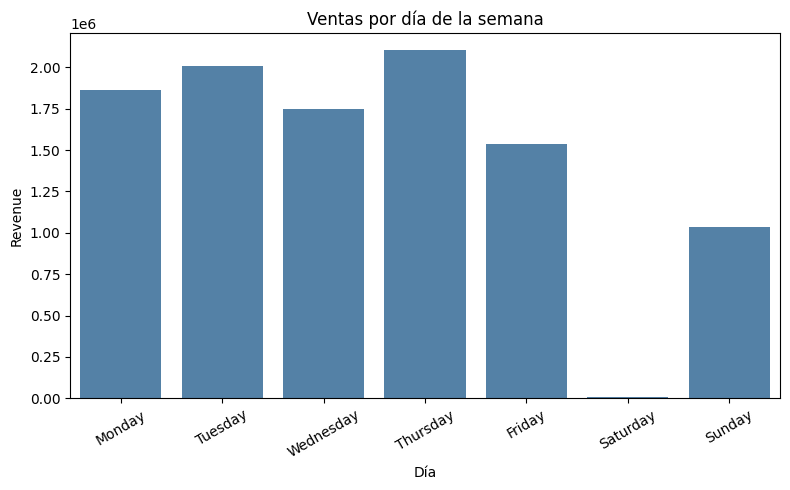

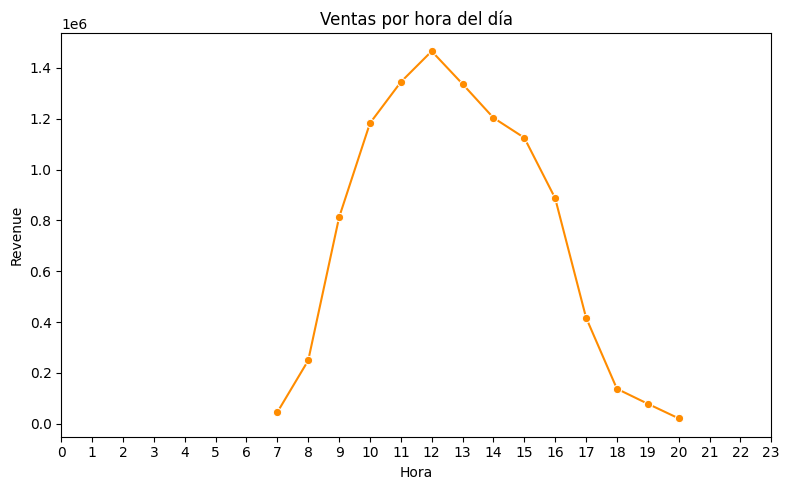

In [47]:
# === BARRAS por día ===
plt.figure(figsize=(8,5))
sns.barplot(data=sales_weekday, x='Weekday', y='Revenue', order=weekday_order, color='steelblue')
plt.title('Ventas por día de la semana')
plt.xlabel('Día')
plt.ylabel('Revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# === LÍNEAS por hora ===
plt.figure(figsize=(8,5))
sns.lineplot(data=sales_hour, x='Hour', y='Revenue', marker='o', color='darkorange')
plt.title('Ventas por hora del día')
plt.xlabel('Hora')
plt.ylabel('Revenue')
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

# RFM de clientes
- Agrupa por Customer ID calcula:
- Recency: días desde la última compra.
- Frequency: número de facturas distintas.
- Monetary: gasto total.

In [48]:
# Fecha de referencia: última fecha del dataset
ref_date = df_sales['InvoiceDate'].max() + pd.Timedelta(days=1)

# RFM
rfm = (
    df_sales.groupby('Customer ID')
    .agg(
        Recency=('InvoiceDate', lambda x: (ref_date - x.max()).days),
        Frequency=('Invoice', 'nunique'),
        Monetary=('Revenue', 'sum')
    )
    .reset_index()
)

# Scores por cuantiles (1 a 5)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print(rfm.sample(20, random_state=42).to_string(index=False))

 Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  RFM_Score
     17576.0        1         23   5434.13        5        5        5         15
     16886.0       92          1    134.00        2        2        1          5
     15518.0       15          7   2276.49        5        5        5         15
     13656.0      135          2    699.20        2        2        3          7
     15620.0       45          1    389.18        3        1        2          6
     16770.0        8          5   1162.03        5        4        4         13
     17742.0       64          9   1743.37        3        5        4         12
     16099.0       53          4    841.30        3        4        3         10
     13045.0       37          2    503.64        3        2        2          7
     14344.0        3         14   2443.77        5        5        5         15
     17352.0      332          1     36.25        1        2        1          4
     13131.0       54       

# Segmentador de clientes
- Clientes VIP
- Clientes Leales
- Nuevos Clientes
- Potenciales Clientes Leales
- Clientes en Riesgo
- Clientes Perdidos

- Recency: días desde la última compra.
- Frequency: número de facturas distintas.
- Monetary: gasto total.

In [49]:
rfm['SegmentRule'] = np.select(
    [
        (rfm['R_Score'] >= 4) & (rfm['F_Score'] >= 4) & (rfm['M_Score'] >= 4),
        (rfm['R_Score'] >= 3) & (rfm['F_Score'] >= 4),
        (rfm['R_Score'] >= 4) & (rfm['F_Score'] <= 2) & (rfm['M_Score'] <= 2),
        (rfm['M_Score'] >= 4) & (rfm['F_Score'] <= 2) & (rfm['R_Score'] >= 3),
        (rfm['R_Score'] >= 4) & (rfm['F_Score'] >= 3) & (rfm['M_Score'] >= 2),
        (rfm['R_Score'] <= 2) & (rfm['F_Score'] >= 3) & (rfm['M_Score'] >= 3),
        (rfm['R_Score'] <= 2) & (rfm['F_Score'] <= 2),
        (rfm['R_Score'].between(2,4)) & (rfm['F_Score'].between(2,4)) & (rfm['M_Score'].between(2,4)),
    ],
    [
        'R>=4 F>=4 M>=4 -> Champions',
        'R>=3 F>=4 -> Loyal',
        'R>=4 F<=2 M<=2 -> New Customers',
        'R>=3 F<=2 M>=3 -> Big Spenders',
        'R>=4 F>=3 M>=2 -> Potential Loyalists',
        'R<=2 F>=3 M>=3 -> At Risk',
        'R<=2 F<=2 -> Lost',
        'R,F,M medios -> Regulars',
    ],
    default='Others'
)


Barplot para ver segmentos:

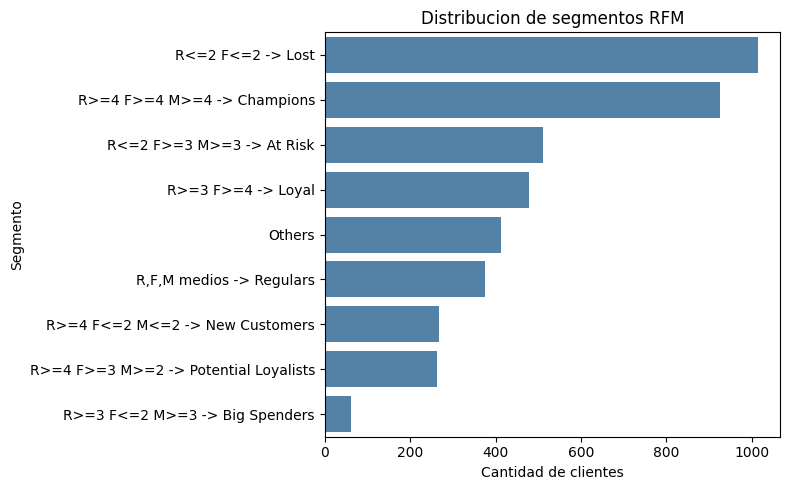

In [50]:
seg_counts = rfm['SegmentRule'].value_counts().reset_index()
seg_counts.columns = ['Segment', 'Count']

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=seg_counts, x='Count', y='Segment', color='steelblue', ax=ax)
ax.set_title('Distribucion de segmentos RFM')
ax.set_xlabel('Cantidad de clientes')
ax.set_ylabel('Segmento')

fig.tight_layout()
fig.savefig(r"C:\Users\ferra\OneDrive\Documentos\Data Projects\ecommerce-sales-analysis\images\segmentos_rfm.png", dpi=300, bbox_inches='tight')
plt.show()

# Exportar CSV

In [52]:
rfm.to_csv(
    r"C:\Users\ferra\OneDrive\Documentos\Data Projects\ecommerce-sales-analysis\data\proccesed\rfm_segments.csv",
    index=False,
    decimal=","
)
